# 2.1 Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,SubsetRandomSampler

# Using device:cpu/cuda

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# 2.2 Download and Preparation of the Dataset. Creating the Dataloaders.

In [3]:
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5,), (0.5,))
 ])

train_dataset = datasets.FashionMNIST(
    'F_MNIST_data', download=True, train=True, transform=transform)
test_dataset = datasets.FashionMNIST(
    'F_MNIST_data', download=True, train=False, transform=transform)

indices = list(range(len(train_dataset)))
np.random.shuffle(indices)
split = int(0.2 * len(train_dataset))
val_ids, train_ids = indices[:split], indices[split:]

train_sampler = SubsetRandomSampler(train_ids)
val_sampler= SubsetRandomSampler(val_ids)

BATCH_SIZE = 128
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader =DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=val_sampler)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 26.4M/26.4M [00:00<00:00, 117MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.11MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 55.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.4MB/s]


# 2.3 Visualisation of the Dataset

Length of train data is 48000
Length of test data is 10000
Length of validation data is 12000
torch.Size([1, 28, 28]) torch.Size([128])
Sneaker


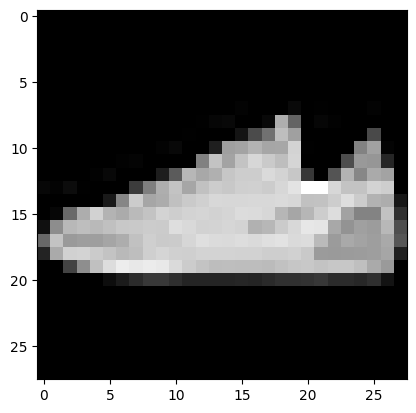

In [4]:
print("Length of train data is " + str(len(train_sampler)))
print("Length of test data is " + str(len(test_dataset)))
print("Length of validation data is " + str(len(val_sampler)))
image, label = next(iter(train_loader))
print(image[0].shape, label.shape) # (1, 28, 28)

desc = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

print(desc[label[0].item()])
plt.imshow(image[0].numpy().squeeze(), cmap='gray')

## BaseCNN — Configurable CNN for Fashion-MNIST Classification
    As per Section 2.4 of the assignment,

### Architecture
    Input (1×28×28)
        → [Conv → (BN) → ReLU → Pool] × (num_blocks - 1)
        → [Conv → (BN) → ReLU]        × 1  (last block, no pool)
        → Flatten
        → FC(fc_hidden) → ReLU → Dropout
        → FC(10)                            (10-class output)

### Parameters
    | Argument    | Type  | Default | Description                                      |
    |-------------|-------|---------|--------------------------------------------------|
    | k           | int   | 2       | Convolution kernel size                          |
    | s           | int   | 1       | Convolution stride                               |
    | num_blocks  | int   | 3       | Number of conv blocks                            |
    | filters     | int   | 64      | Number of output channels in every conv layer    |
    | fc_hidden   | int   | 64      | Hidden size of the first FC layer                |
    | dropout_p   | float | 0.0     | Dropout probability after hidden FC (0=disabled) |
    | use_bn      | bool  | False   | Insert BatchNorm2d after every Conv2d if True    |

### Experiments (as per assignment Table 1)
    | Exp | k | s | num_blocks | dropout_p | use_bn |
    |-----|---|---|------------|-----------|--------|
    | 1   | 2 | 1 | 3          | 0.00      | No     |
    | 2   | 5 | 2 | 1          | 0.00      | No     |
    | 3   | 2 | 1 | 2          | 0.00      | No     |
    | 4   | 2 | 1 | 3          | 0.25      | No     |
    | 5   | best model + BN=True                    |

In [5]:
class BaseCNN(nn.Module):
    def __init__(self, kernel_size=2, stride=1, num_blocks=3,
                 filters=64, fc_hidden=64, dropout_p=0.0, use_bn=False):
        super().__init__()
        self.num_blocks = num_blocks
        padding = 0  # as in the assignment (no padding specified)

        conv_blocks = []
        in_ch = 1
        for i in range(num_blocks):
            conv_blocks.append(nn.Conv2d(in_ch, filters, kernel_size, stride=stride, padding=padding))
            if use_bn:
                conv_blocks.append(nn.BatchNorm2d(filters))
            conv_blocks.append(nn.ReLU())
            # All blocks except the last get a 2×2 max-pool (assignment spec)
            if i < num_blocks - 1:
                conv_blocks.append(nn.MaxPool2d(2, 2))
            in_ch = filters

        self.conv_net = nn.Sequential(*conv_blocks)

        # Compute flattened size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            flat_size = self.conv_net(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(fc_hidden, 10),
        )

    def forward(self, x):
        x = self.conv_net(x)
        return self.classifier(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


## train_one_epoch — Runs one full training epoch over the dataset

### What it does
    - Sets model to training mode (`model.train()`)
    - Loops over all batches in the loader
    - For each batch: forward pass → loss → backward pass → weight update
    - Tracks running loss and accuracy across all batches
    - Displays a progress bar with live batch loss and accuracy

### Parameters
    | Argument   | Type              | Description                              |
    |------------|-------------------|------------------------------------------|
    | model      | nn.Module         | The CNN model to train                   |
    | loader     | DataLoader        | Training dataloader (batch size 128)     |
    | optimizer  | optim.Adam        | Adam optimiser (lr=0.001)                |
    | criterion  | nn.CrossEntropy   | Cross entropy loss function              |
    | epoch      | int               | Current epoch number (used in tqdm desc) |
    | exp_name   | str               | Experiment name (used in tqdm desc)      |

### Returns
    | Value       | Description                                      |
    |-------------|--------------------------------------------------|
    | total_loss  | Average loss over all samples in the epoch       |
    | accuracy    | Fraction of correctly classified samples         |

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, epoch, exp_name):
    model.train()
    total_loss, correct, total = 0.0, 0, 0


    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += X.size(0)

    return total_loss / total, correct / total

### Evaluates model on a dataloader (val or test) without gradient computation.

- Args:
        model     (nn.Module)    : CNN model to evaluate
        loader    (DataLoader)   : val or test dataloader
        criterion (nn.Module)    : cross entropy loss function

- Returns:
        avg_loss  (float) : average loss over all samples
        accuracy  (float) : fraction of correctly classified samples

In [7]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        out = model(X)
        loss = criterion(out, y)
        total_loss += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total

## `show_activation_maps` — Visualises CNN Feature Maps During Training

Displays the **mean activation map** across all filters for every `Conv2d` layer in the model. Called every 10 epochs to track how the network's feature extraction evolves over training.

---

### How it works
1. Passes `sample_img` through `conv_net` **layer by layer**
2. After each `Conv2d`, captures the output of shape `(64, H, W)`
3. Averages across all 64 filters → single `(H, W)` map per conv layer
4. Plots all conv layers **side by side** in one figure

---

### Arguments
| Argument     | Type       | Description                                  |
|--------------|------------|----------------------------------------------|
| `model`      | nn.Module  | CNN model to extract activations from        |
| `sample_img` | Tensor     | Input image, shape `(1,1,28,28)` or `(1,28,28)` |
| `epoch`      | int        | Current epoch number (shown in plot title)   |
| `exp_name`   | str        | Experiment name (shown in plot title)        |

---

### Output
One figure with `num_conv_layers` subplots side by side:
```
Exp1_Baseline | Mean Activation | Epoch 10
┌──────────┬──────────┬──────────┐
│  Conv 1  │  Conv 2  │  Conv 3  │
│ (27×27)  │  (5×5)   │  (5×5)   │
└──────────┴──────────┴──────────┘
```

In [8]:
def show_activation_maps(model, sample_img, epoch, exp_name):
    """
    Display mean activation map across all filters for every Conv2d layer.
    sample_img : (1, 1, 28, 28) tensor on CPU
    """
    if sample_img.dim() == 3:
        sample_img = sample_img.unsqueeze(0)
    model.eval()
    activations = []
    x = sample_img.to(device)

    with torch.no_grad():
        for layer in model.conv_net:
            x = layer(x)
            if isinstance(layer, nn.Conv2d):
                activations.append(x.squeeze(0).cpu())  # (C, H, W)

    fig, axes = plt.subplots(1, len(activations), figsize=(len(activations) * 3, 3))
    axes = np.array(axes).reshape(-1)

    for conv_idx, act in enumerate(activations):
        mean_map = act.mean(dim=0).numpy()  # average across all 64 filters → (H, W)
        axes[conv_idx].imshow(mean_map, cmap='viridis')
        axes[conv_idx].axis('off')
        axes[conv_idx].set_title(f'Conv {conv_idx+1}', fontsize=9)

    fig.suptitle(f'{exp_name} | Mean Activation | Epoch {epoch}', fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

## Fixed Sample Image for Activation Map Visualisation

A single test image is selected **once before training** and reused across
all experiments and all epochs to ensure activation maps are **directly comparable**.

---

### Why fix the sample image?
- If a different image were used each epoch, changes in activation maps
  could be due to the **image changing** rather than the **weights changing**
- Using the same image across all 5 experiments lets us see how
  different architectures respond to **identical input**

---

### What this cell does
1. Sets `EPOCHS = 50` as required by the assignment
2. Grabs the **first batch** from `test_loader`
3. Selects the **first image** from that batch → shape `(1, 28, 28)`
4. Displays the image and its class label using `desc[]`


Sample image class: Ankle Boot


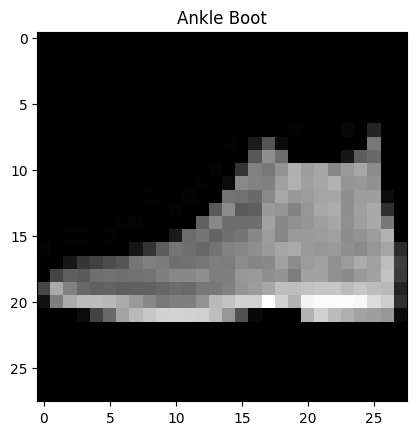

In [9]:
EPOCHS = 50
# Grab a fixed sample image for activation maps
sample_image, sample_label = next(iter(test_loader))
sample_image = sample_image[0]   # shape: (1, 28, 28)
print(f"\nSample image class: {desc[sample_label[0].item()]}")
plt.imshow(sample_image.numpy().squeeze(), cmap='gray')
plt.title(desc[sample_label[0].item()])
plt.show()

## `run_experiment` — Full Training Pipeline for One Experiment

Trains a `BaseCNN` model for 50 epochs and reports all metrics required by the assignment.

---

### Pipeline
1. **Initialise** model, Adam optimiser (lr=0.001), CrossEntropy loss
2. **Train** 50 epochs — logs train/val loss and accuracy each epoch via tqdm
3. **Every 10 epochs** — prints metrics and shows mean activation maps
4. **After training** — evaluates on test set and plots loss & accuracy curves

---

### Returns
| Key         | Description                          |
|-------------|--------------------------------------|
| `exp_name`  | Experiment name                      |
| `n_params`  | Total trainable parameters           |
| `train_acc` | Final training accuracy (%)          |
| `val_acc`   | Final validation accuracy (%)        |
| `test_acc`  | Test accuracy (%)                    |
| `history`   | Dict of loss/accuracy across epochs  |
| `model`     | Trained model object                 |

In [10]:
def run_experiment(exp_name, model_kwargs):
    print(f"\n{'='*60}")
    print(f"  {exp_name}")
    print(f"{'='*60}")

    model = BaseCNN(**model_kwargs).to(device)
    n_params = model.count_parameters()
    print(f"  Trainable parameters: {n_params:,}")

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}


    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion,epoch,exp_name)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)


        if epoch % 10 == 0:
            print(f"\n{'='*30}")
            print(f"After {epoch} epochs,")
            print(f"{'='*30}")
            print(f'Training Loss: {tr_loss:.4f}, Training Accuracy:  {tr_acc*100:.2f}%, Validation loss: {vl_loss:.4f}, Validation Accuracy:  {vl_acc*100:.2f}%')
            show_activation_maps(model, sample_image, epoch, exp_name)

    # Test accuracy
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"\n  Final Train Acc : {history['train_acc'][-1]*100:.2f}%")
    print(f"  Final Val   Acc : {history['val_acc'][-1]*100:.2f}%")
    print(f"  Test        Acc : {test_acc*100:.2f}%")

   # Plot loss & accuracy curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(1, EPOCHS + 1)

    axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss')
    axes[0].set_title(f'{exp_name} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc')
    axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc')
    axes[1].axhline(test_acc*100, color='red', linestyle='--', label=f'Test Acc {test_acc*100:.2f}%')
    axes[1].set_title(f'{exp_name} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

    return {
        'exp_name':   exp_name,
        'n_params':   n_params,
        'train_acc':  history['train_acc'][-1] * 100,
        'val_acc':    history['val_acc'][-1]   * 100,
        'test_acc':   test_acc * 100,
        'history':    history,
        'model':      model,
    }


## 3 Assignments to Solve and Report
### Experiment 1 — Baseline
Default configuration as specified in the assignment.

| Parameter    | Value |
|--------------|-------|
| kernel_size  | 2     |
| stride       | 1     |
| num_blocks   | 3     |
| dropout_p    | 0.00  |
| use_bn       | False |



  Exp1_Baseline
  Trainable parameters: 136,330

After 10 epochs,
Training Loss: 0.1799, Training Accuracy:  93.40%, Validation loss: 0.2461, Validation Accuracy:  91.40%


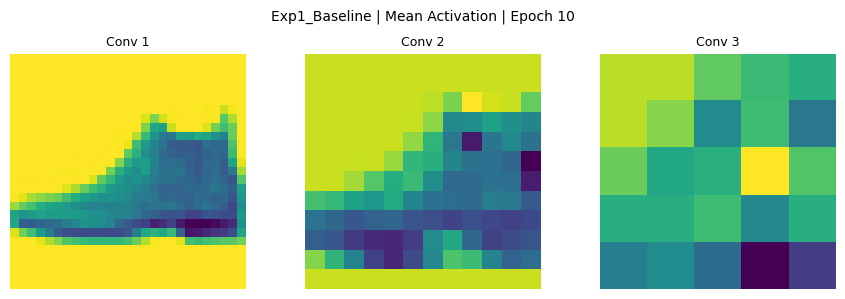


After 20 epochs,
Training Loss: 0.0864, Training Accuracy:  96.76%, Validation loss: 0.3025, Validation Accuracy:  91.42%


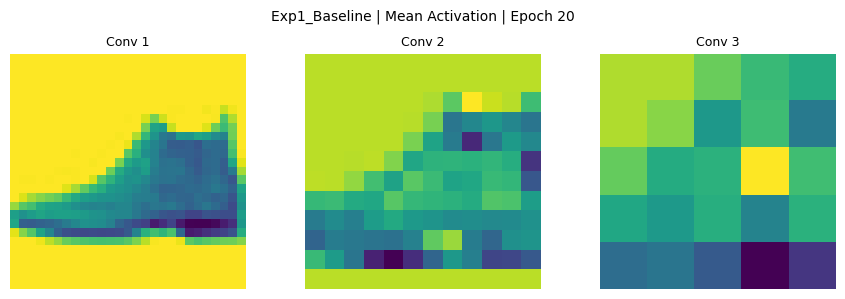


After 30 epochs,
Training Loss: 0.0366, Training Accuracy:  98.60%, Validation loss: 0.4346, Validation Accuracy:  91.00%


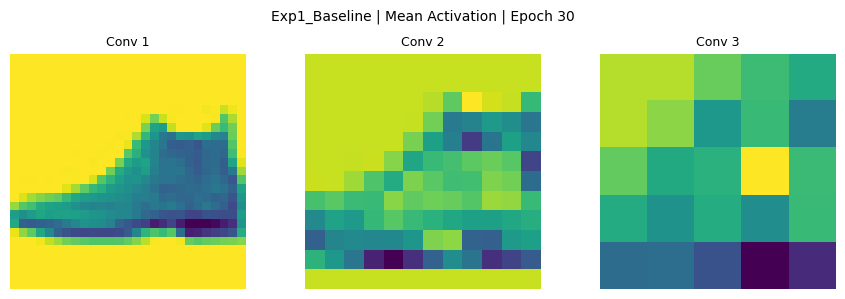


After 40 epochs,
Training Loss: 0.0253, Training Accuracy:  99.12%, Validation loss: 0.5826, Validation Accuracy:  91.27%


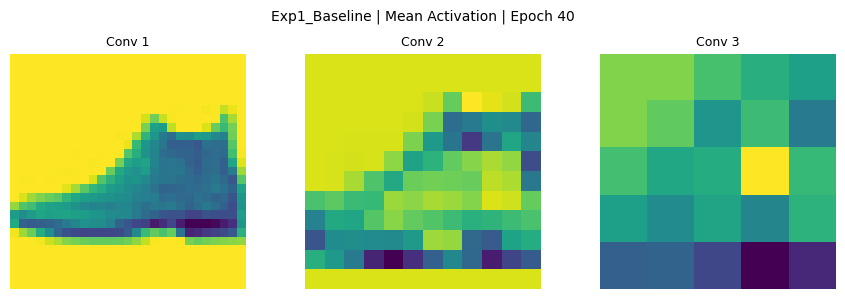


After 50 epochs,
Training Loss: 0.0163, Training Accuracy:  99.40%, Validation loss: 0.6784, Validation Accuracy:  90.56%


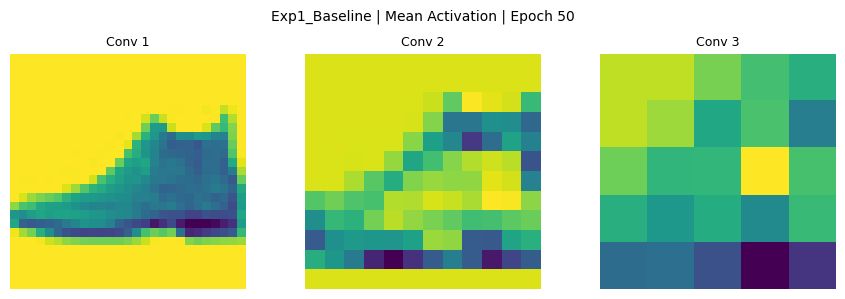


  Final Train Acc : 99.40%
  Final Val   Acc : 90.56%
  Test        Acc : 90.20%


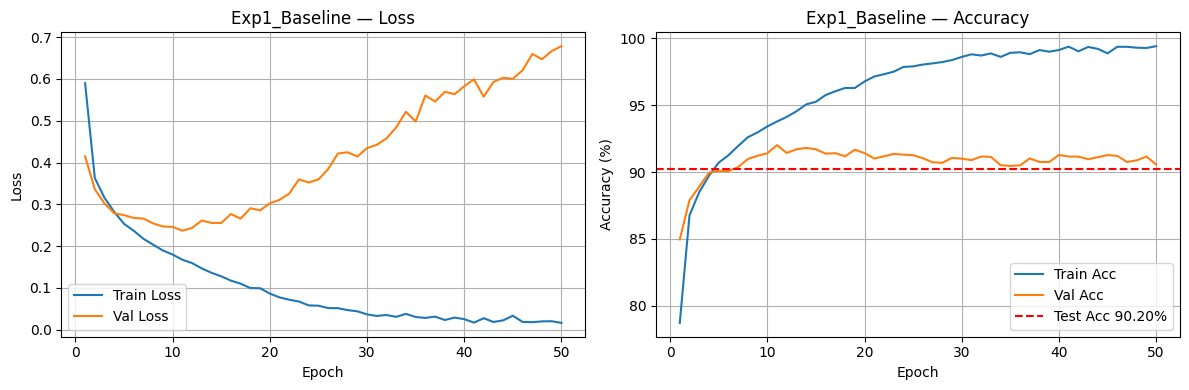

In [11]:
exp1 = run_experiment(
    "Exp1_Baseline",
    dict(kernel_size=2, stride=1, num_blocks=3, filters=64,
         fc_hidden=64, dropout_p=0.0, use_bn=False)
)

### Experiment 2 — Kernel Size & Stride Ablation
Tests the effect of a **larger kernel**, **higher stride** and **lesser depth** on performance.

| Parameter    | Value     |
|--------------|-----------|
| kernel_size  | **5**     |
| stride       | **2**     |
| num_blocks   | 1         |
| dropout_p    | 0.00      |
| use_bn       | False     |


  Exp2_Kernel5_Stride2
  Trainable parameters: 592,202

After 10 epochs,
Training Loss: 0.1096, Training Accuracy:  96.01%, Validation loss: 0.3075, Validation Accuracy:  90.42%


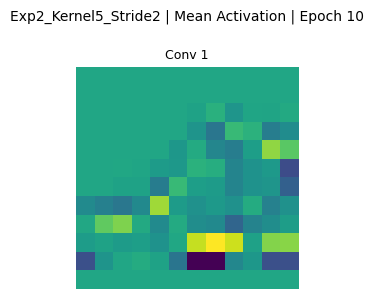


After 20 epochs,
Training Loss: 0.0298, Training Accuracy:  99.02%, Validation loss: 0.4968, Validation Accuracy:  90.12%


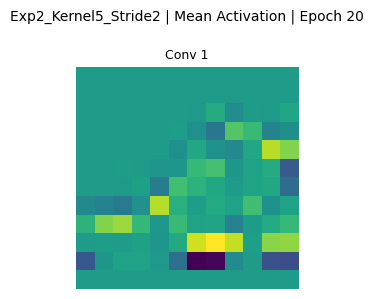


After 30 epochs,
Training Loss: 0.0102, Training Accuracy:  99.70%, Validation loss: 0.6618, Validation Accuracy:  89.79%


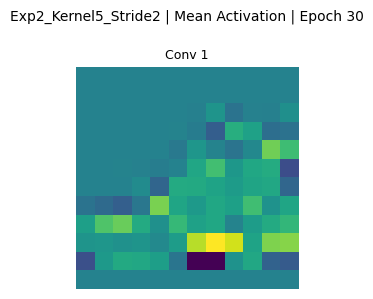


After 40 epochs,
Training Loss: 0.0004, Training Accuracy:  100.00%, Validation loss: 0.7549, Validation Accuracy:  90.34%


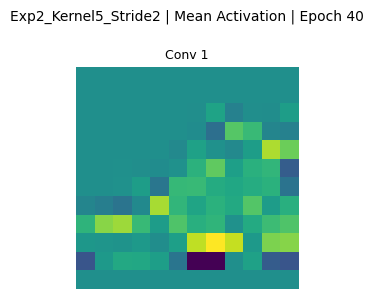


After 50 epochs,
Training Loss: 0.0011, Training Accuracy:  99.99%, Validation loss: 0.8332, Validation Accuracy:  89.81%


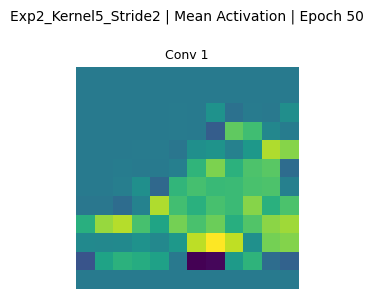


  Final Train Acc : 99.99%
  Final Val   Acc : 89.81%
  Test        Acc : 90.25%


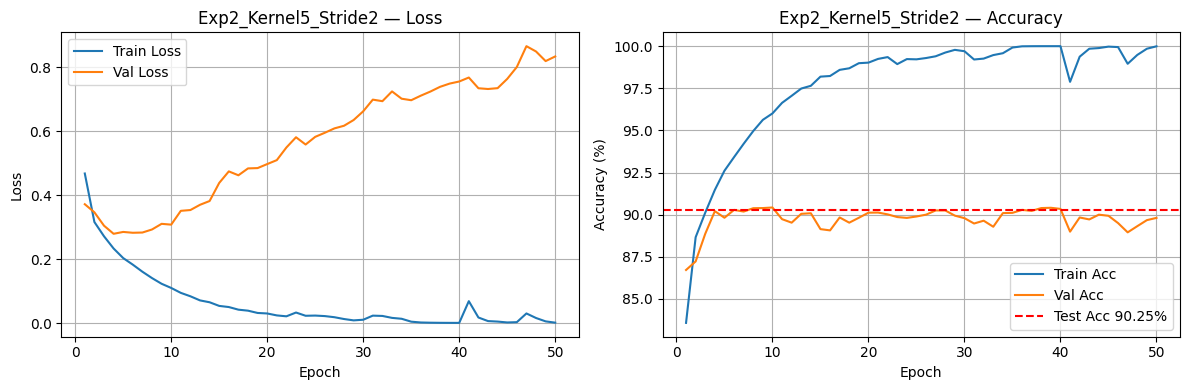

In [12]:
exp2 = run_experiment(
    "Exp2_Kernel5_Stride2",
    dict(kernel_size=5, stride=2, num_blocks=1, filters=64,
         fc_hidden=64, dropout_p=0.0, use_bn=False)
)

### Experiment 3 — Depth Ablation (Shallower)
Tests the effect of **removing one conv block** on performance.

| Parameter    | Value     |
|--------------|-----------|
| kernel_size  | 2         |
| stride       | 1         |
| num_blocks   | **2**     |
| dropout_p    | 0.00      |
| use_bn       | False     |


  Exp3_Depth2
  Trainable parameters: 607,306

After 10 epochs,
Training Loss: 0.1308, Training Accuracy:  95.23%, Validation loss: 0.2754, Validation Accuracy:  90.82%


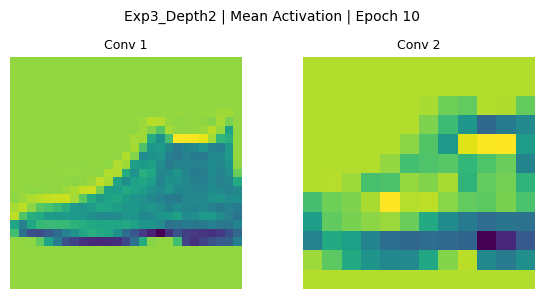


After 20 epochs,
Training Loss: 0.0325, Training Accuracy:  98.86%, Validation loss: 0.4313, Validation Accuracy:  91.12%


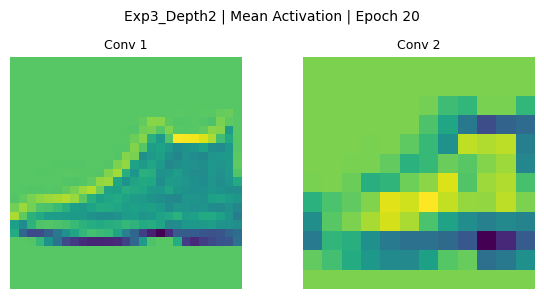


After 30 epochs,
Training Loss: 0.0165, Training Accuracy:  99.45%, Validation loss: 0.5809, Validation Accuracy:  90.83%


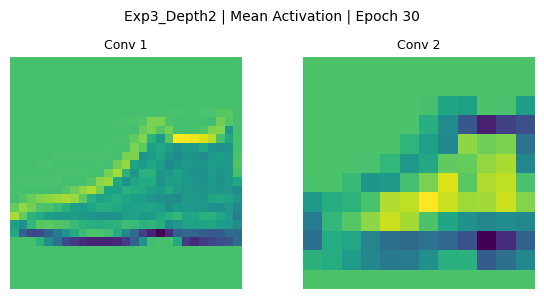


After 40 epochs,
Training Loss: 0.0059, Training Accuracy:  99.81%, Validation loss: 0.6660, Validation Accuracy:  91.07%


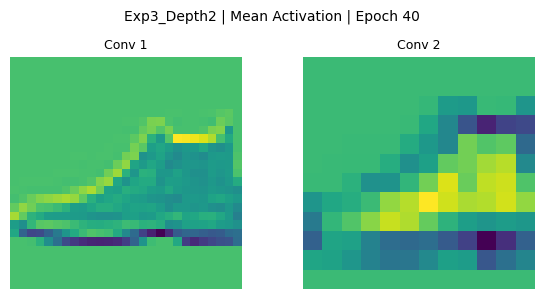


After 50 epochs,
Training Loss: 0.0079, Training Accuracy:  99.74%, Validation loss: 0.7529, Validation Accuracy:  90.67%


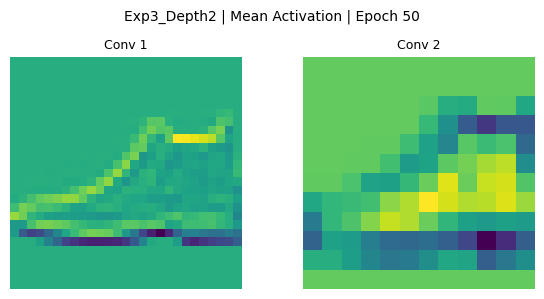


  Final Train Acc : 99.74%
  Final Val   Acc : 90.67%
  Test        Acc : 90.56%


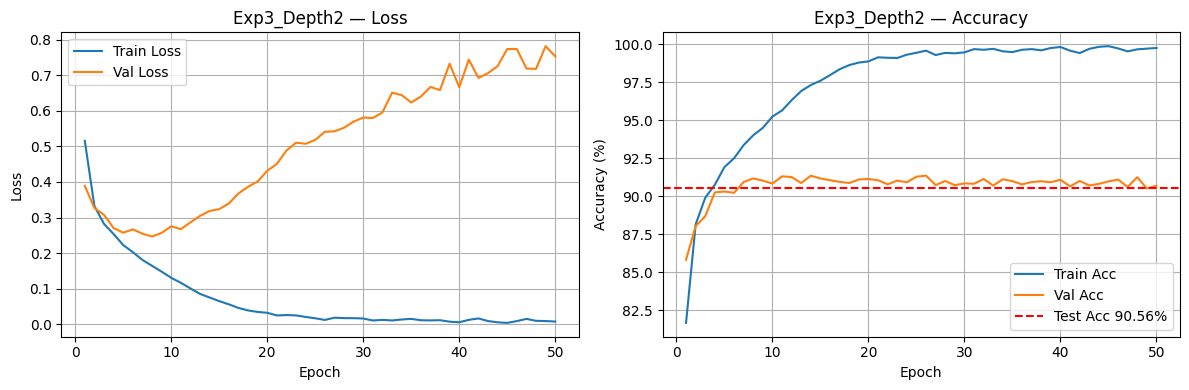

In [13]:
exp3 = run_experiment(
    "Exp3_Depth2",
    dict(kernel_size=2, stride=1, num_blocks=2, filters=64,
         fc_hidden=64, dropout_p=0.0, use_bn=False)
)

### Experiment 4 — Dropout Regularisation
Tests the effect of **dropout (p=0.25)** after the hidden FC layer.

| Parameter    | Value     |
|--------------|-----------|
| kernel_size  | 2         |
| stride       | 1         |
| num_blocks   | 3         |
| dropout_p    | **0.25**  |
| use_bn       | False     |



  Exp4_Dropout025
  Trainable parameters: 136,330

After 10 epochs,
Training Loss: 0.2250, Training Accuracy:  91.74%, Validation loss: 0.2416, Validation Accuracy:  91.25%


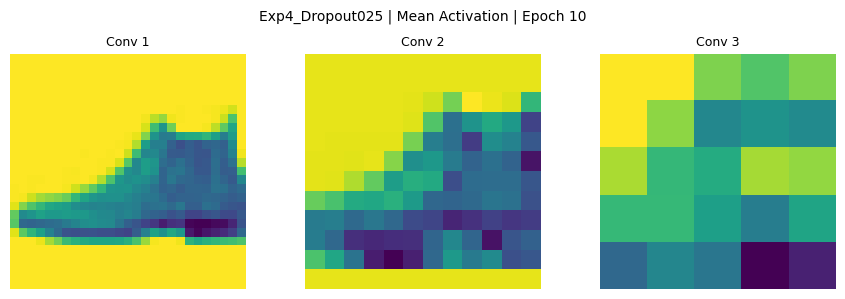


After 20 epochs,
Training Loss: 0.1413, Training Accuracy:  94.59%, Validation loss: 0.2671, Validation Accuracy:  91.55%


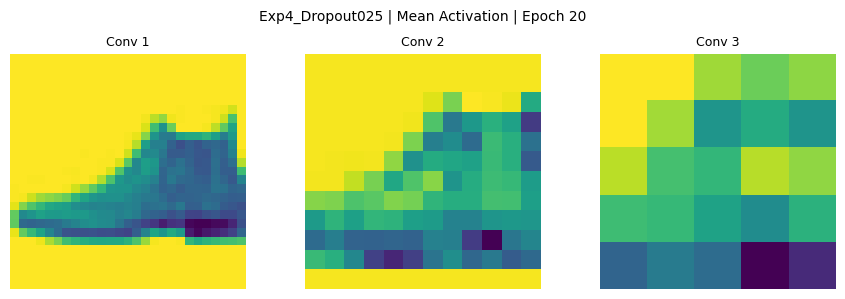


After 30 epochs,
Training Loss: 0.0959, Training Accuracy:  96.19%, Validation loss: 0.3196, Validation Accuracy:  91.58%


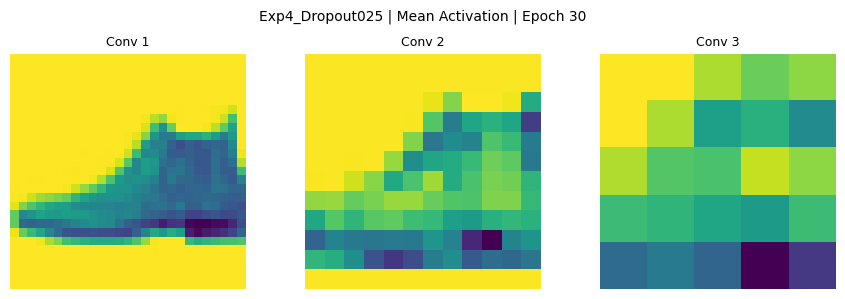


After 40 epochs,
Training Loss: 0.0728, Training Accuracy:  97.05%, Validation loss: 0.3878, Validation Accuracy:  91.75%


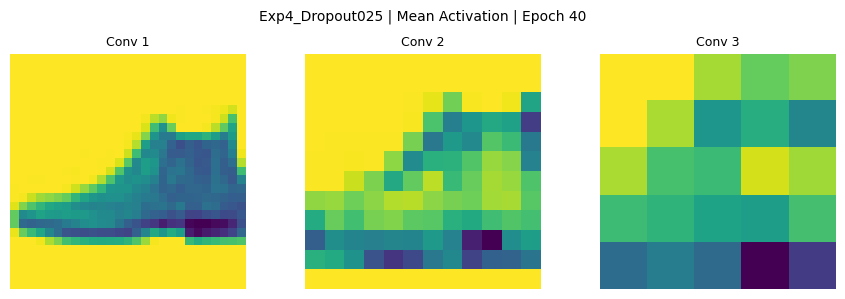


After 50 epochs,
Training Loss: 0.0620, Training Accuracy:  97.53%, Validation loss: 0.4534, Validation Accuracy:  91.37%


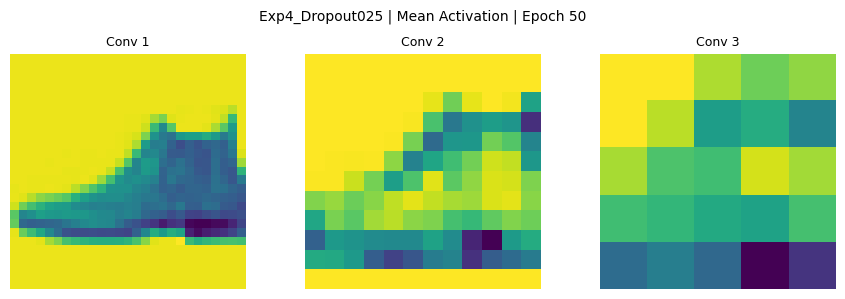


  Final Train Acc : 97.53%
  Final Val   Acc : 91.37%
  Test        Acc : 91.02%


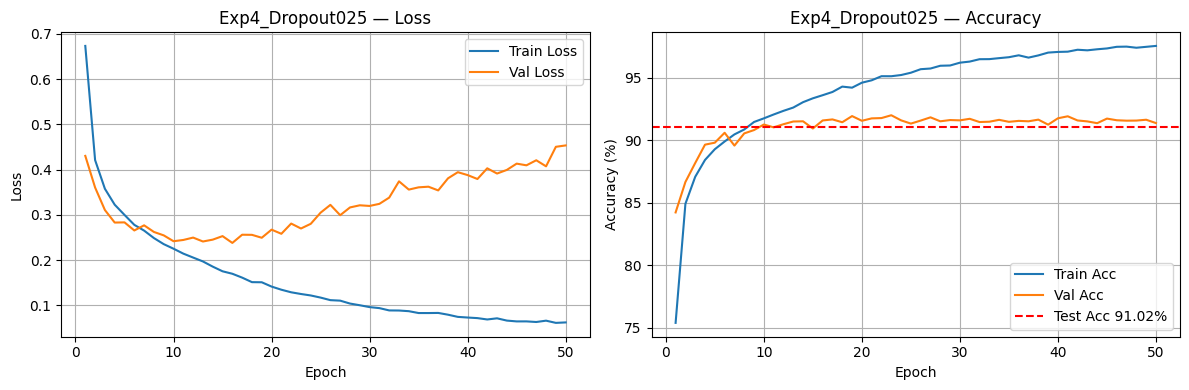

In [14]:
exp4 = run_experiment(
    "Exp4_Dropout025",
    dict(kernel_size=2, stride=1, num_blocks=3, filters=64,
         fc_hidden=64, dropout_p=0.25, use_bn=False)
)

## Finds the best performing model from 1,2,3,4

In [15]:
results = [exp1, exp2, exp3, exp4]
best = max(results, key=lambda r: r['val_acc'])
print(f"\nBest model (Exp 1-4): {best['exp_name']}  Val Acc = {best['val_acc']:.2f}%")


Best model (Exp 1-4): Exp4_Dropout025  Val Acc = 91.37%


### Experiment 5 — Batch Normalisation
Adds **BatchNorm2d** after every Conv2d layer to the best performing model from Exp 1-4.

| Parameter    | Value         |
|--------------|---------------|
| kernel_size  | best model    |
| stride       | best model    |
| num_blocks   | best model    |
| dropout_p    | best model    |
| use_bn       | **True**      |


  Exp5_BestModel_BN
  Trainable parameters: 136,714

After 10 epochs,
Training Loss: 0.1430, Training Accuracy:  94.69%, Validation loss: 0.2449, Validation Accuracy:  91.54%


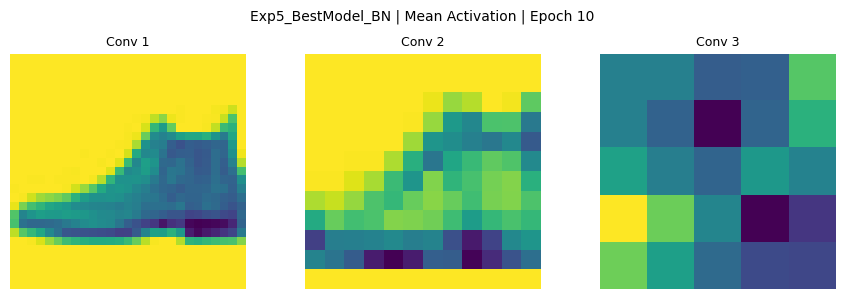


After 20 epochs,
Training Loss: 0.0723, Training Accuracy:  97.21%, Validation loss: 0.3052, Validation Accuracy:  91.31%


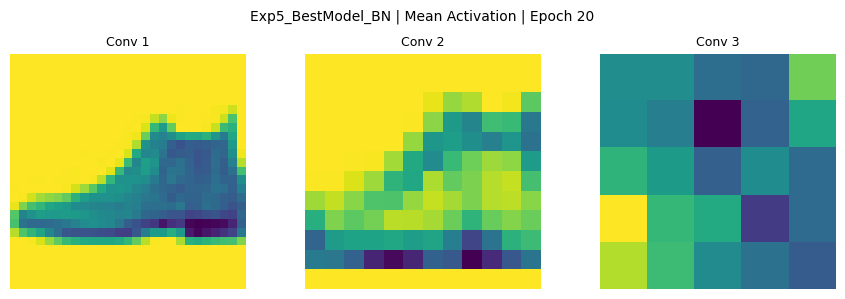


After 30 epochs,
Training Loss: 0.0448, Training Accuracy:  98.33%, Validation loss: 0.3662, Validation Accuracy:  92.03%


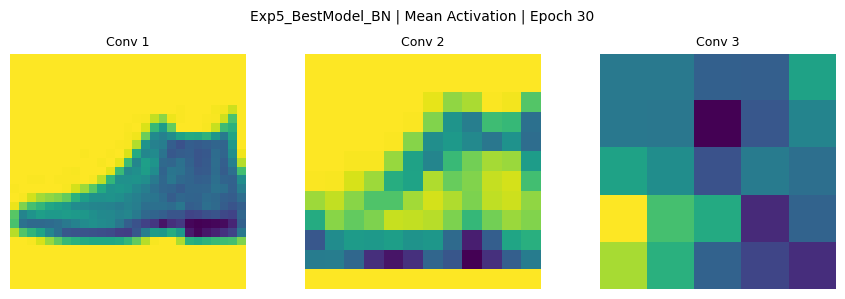


After 40 epochs,
Training Loss: 0.0383, Training Accuracy:  98.54%, Validation loss: 0.4771, Validation Accuracy:  91.72%


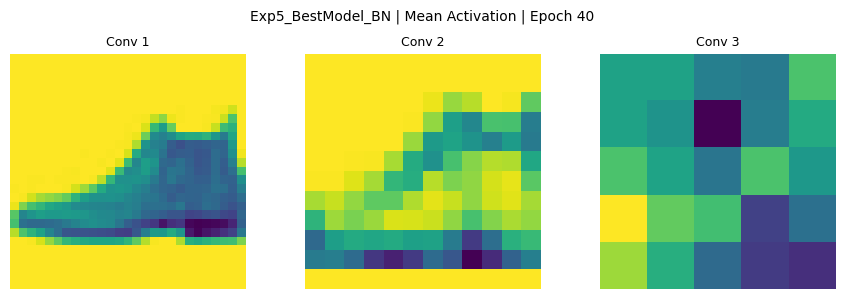


After 50 epochs,
Training Loss: 0.0290, Training Accuracy:  98.91%, Validation loss: 0.4835, Validation Accuracy:  91.72%


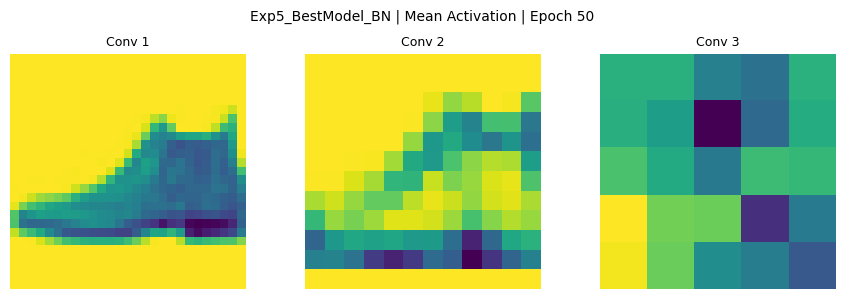


  Final Train Acc : 98.91%
  Final Val   Acc : 91.72%
  Test        Acc : 91.67%


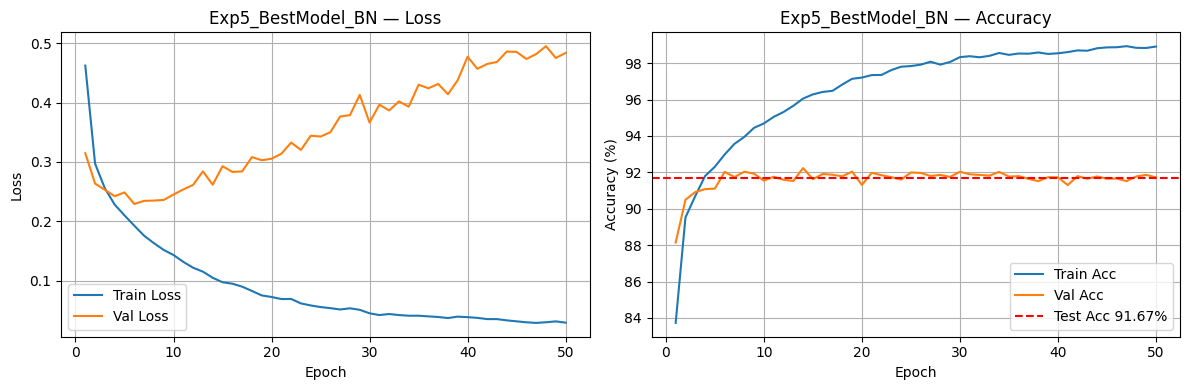

In [16]:
best_kwargs_map = {
    "Exp1_Baseline":      dict(kernel_size=2, stride=1, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.00),
    "Exp2_Kernel5_Stride2": dict(kernel_size=5, stride=2, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.00),
    "Exp3_Depth2":        dict(kernel_size=2, stride=1, num_blocks=2, filters=64, fc_hidden=64, dropout_p=0.00),
    "Exp4_Dropout025":    dict(kernel_size=2, stride=1, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.25),
}
best_kw = best_kwargs_map[best['exp_name']]
best_kw['use_bn'] = True

exp5 = run_experiment("Exp5_BestModel_BN", best_kw)

## Summary Table

| Exp | Model Name           | Kernel | Stride | Depth | Dropout | BN  | Overfitting | Generalization |
|-----|----------------------|--------|--------|-------|---------|-----|-------------|----------------|
| 1   | Baseline             | 2      | 1      | 3     | 0.00    | No  | Moderate    | Moderate       |
| 2   | Kernel5_Stride2      | 5      | 2      | 1     | 0.00    | No  | Severe      | Low            |
| 3   | Depth2               | 2      | 1      | 2     | 0.00    | No  | Severe      | Moderate       |
| 4   | Dropout025           | 2      | 1      | 3     | 0.25    | No  | Reduced     | Good           |
| 5   | BestModel_BN         | 2      | 1      | 3     | 0.25    | Yes | Minimal     | **Best**       |

## Key Observations

- **Architectural changes alone** (larger kernel, reduced depth) do not improve
  generalization and can worsen overfitting without explicit regularization.
- **Dropout** is the first intervention that meaningfully reduces the train-validation gap,
  acting as an effective stochastic regularizer on the FC layers.
- **Batch Normalization**, when combined with dropout, yields the most stable training
  dynamics, fastest convergence, and best generalization to unseen data.
- Hence, The final model works the best.